In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [7]:
%%time
import pandas as pd
data = pd.read_csv("galaxyquasar.csv")
data

CPU times: total: 62.5 ms
Wall time: 89.3 ms


,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['class'] = le.fit_transform(data['class'])
labels = le.inverse_transform(data['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [19]:
import tensorflow as tf
from tensorflow import keras

keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

In [53]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(data.drop('class', axis=1), data['class'], test_size=0.30, random_state=42)

print(X_train_full.shape)
print(X_test.shape)

X_train, X_valid,  y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.30, random_state=42)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(35000, 7)
(15000, 7)
(24500, 7)
(10500, 7)
(15000, 7)


In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)

X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)

In [55]:
# Need to Convert to NumPy and reshape for CNN
Xtrain = X_train_s[:, :, np.newaxis]
Xvalid = X_valid_s[:, :, np.newaxis]
Xtest = X_test_s[:, :, np.newaxis]

print(Xtrain.shape)
print(Xvalid.shape)
print(Xtest.shape)

(24500, 7, 1)
(10500, 7, 1)
(15000, 7, 1)


In [56]:
model = keras.models.Sequential([
    keras.layers.InputLayer(shape=[7, 1]),
    keras.layers.Conv1D(filters=7, kernel_size=3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(14, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(14, 3, activation='relu', padding='same'),  
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=14, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=7, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
]) 

In [57]:
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 7, 7)           │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 3, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 3, 14)          │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 3, 14)          │           602 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 1, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,269 (4.96 KB)

 Trainable params: 1,269 (4.96 KB)

 Non-trainable params: 0 (0.00 B)

None


In [58]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(Xtrain, y_train, epochs=10, validation_data=(Xvalid, y_valid))

Epoch 1/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8490 - loss: 0.3924 - val_accuracy: 0.9832 - val_loss: 0.0764
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9467 - loss: 0.1349 - val_accuracy: 0.9855 - val_loss: 0.0541
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9554 - loss: 0.1078 - val_accuracy: 0.9885 - val_loss: 0.0467
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9567 - loss: 0.0956 - val_accuracy: 0.9889 - val_loss: 0.0464
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9560 - loss: 0.0945 - val_accuracy: 0.9894 - val_loss: 0.0434
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9568 - loss: 0.0921 - val_accuracy: 0.9898 - val_loss: 0.0442
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9613 - loss: 0.0861 - val_accuracy: 0.9891 - val_loss: 0.0425
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9552 - loss: 0.0893 - val_accuracy: 0.

Looks like very good results!

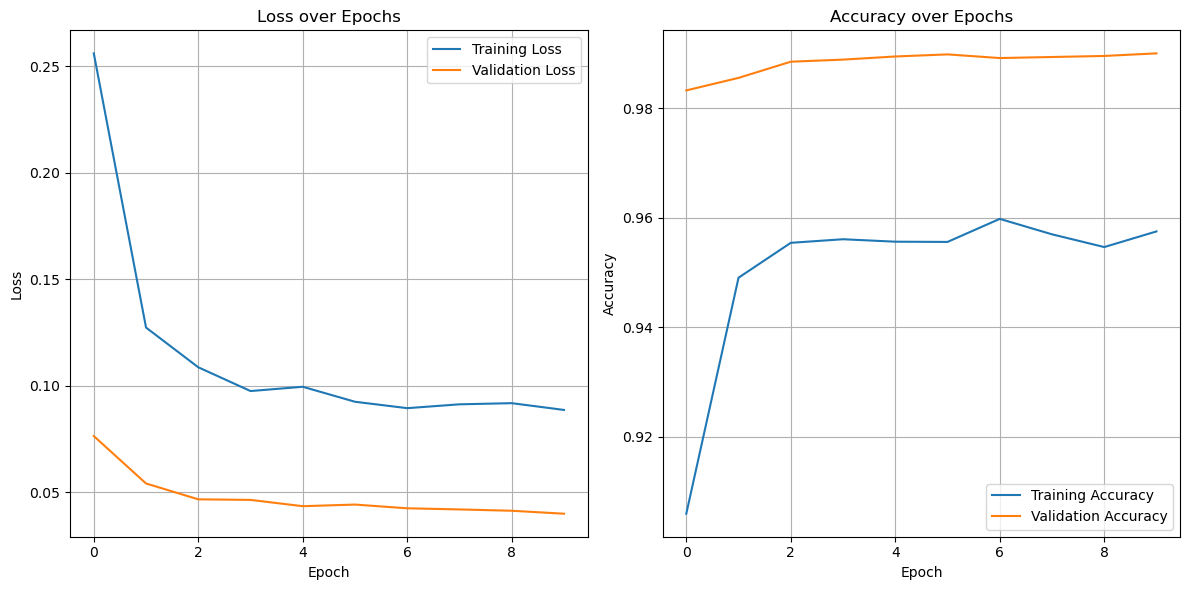

In [59]:
training_loss = clf.history['loss']
validation_loss = clf.history['val_loss']

training_accuracy = clf.history['accuracy']
validation_accuracy = clf.history['val_accuracy']

# Plots

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Let's plot the predictions on the validation set, considering the u-g band, since in homework 14 (14_GalaxyClassifier(19).ipynb) is shown how, over all colors, this band is the one where the data bimodality (Quasar or Galaxy object) is highlighted the most.

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


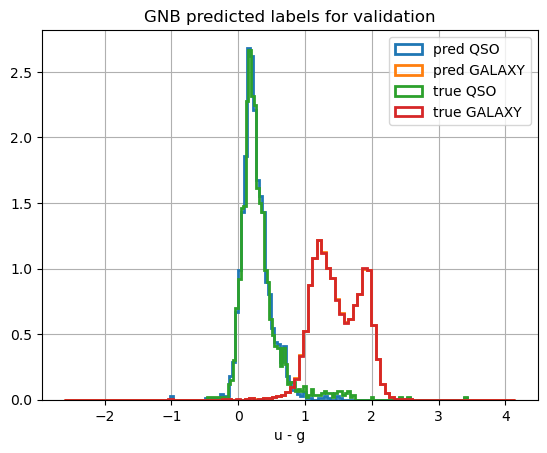

In [84]:
y_proba = model.predict(Xvalid)
y_pred = np.argmax(y_proba, axis=-1)


#plot
plt.hist(x=(X_valid['u']-X_valid['g'])[y_pred==1], histtype='step',bins=100, linewidth=2, density=True, label='pred QSO')
plt.hist(x=(X_valid['u']-X_valid['g'])[y_pred==0], histtype='step',bins=100, linewidth=2, density=True, label='pred GALAXY')
plt.xlabel('u - g')

plt.hist(x=(X_valid['u']-X_valid['g'])[y_valid==1], histtype='step',bins=100, linewidth=2, density=True, label='true QSO')
plt.hist(x=(X_valid['u']-X_valid['g'])[y_valid==0], histtype='step',bins=100, linewidth=2, density=True, label='true GALAXY')
plt.xlabel('u - g')

plt.title('GNB predicted labels for validation')
plt.legend()
plt.grid(True)
plt.show()

Very good! Let's then see how good the model predict on the test set:

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


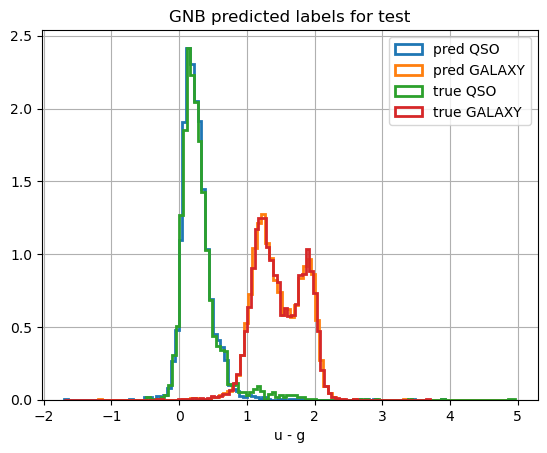

In [85]:
y_proba = model.predict(Xtest)
y_pred = np.argmax(y_proba, axis=-1)


#plot
plt.hist(x=(X_test['u']-X_test['g'])[y_pred==1], histtype='step',bins=100, linewidth=2, density=True, label='pred QSO')
plt.hist(x=(X_test['u']-X_test['g'])[y_pred==0], histtype='step',bins=100, linewidth=2, density=True, label='pred GALAXY')
plt.xlabel('u - g')

plt.hist(x=(X_test['u']-X_test['g'])[y_test==1], histtype='step',bins=100, linewidth=2, density=True, label='true QSO')
plt.hist(x=(X_test['u']-X_test['g'])[y_test==0], histtype='step',bins=100, linewidth=2, density=True, label='true GALAXY')
plt.xlabel('u - g')

plt.title('GNB predicted labels for test')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from astroML.utils import completeness_contamination

test_loss, test_accuracy = model.evaluate(Xtest, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
C = confusion_matrix(y_test, y_pred)
print(C)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0401
Test Loss: 0.0363
Test Accuracy: 0.9914
[[12778    34]
 [   95  2093]]


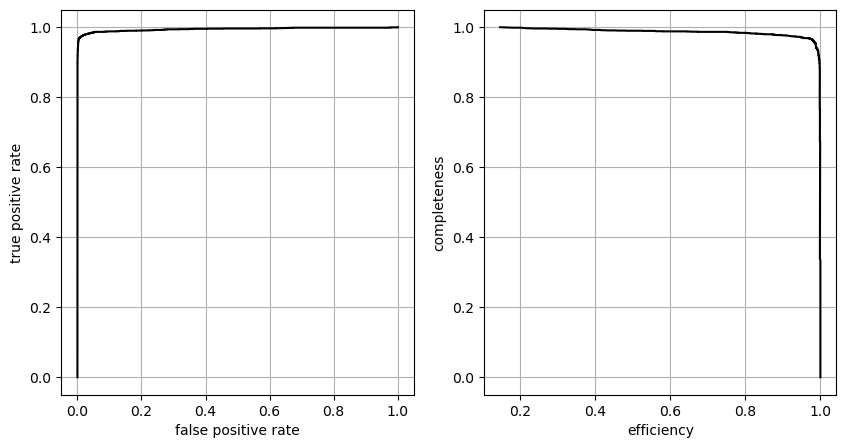

In [87]:
fpr, tpr, th = roc_curve(y_test, y_proba[:,1])
#precision, recall, th2 = precision_recall_curve(y_test, y_prob)

thresholds = np.linspace(0, 1, 50001)[:-1]
comp = np.zeros_like(thresholds)
cont = np.zeros_like(thresholds)
for i, t in enumerate(thresholds):
    y_pred = (y_proba[:,1] >= t)
    comp[i], cont[i] = completeness_contamination(y_pred, y_test)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(fpr, tpr, 'black')
ax[0].set_xlabel('false positive rate')
ax[0].set_ylabel('true positive rate')
ax[1].plot(1-cont, comp, 'black')
ax[1].set_xlabel('efficiency')
ax[1].set_ylabel('completeness')
[ax[i].grid(True) for i in range(2)]
plt.show()